In [ ]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import os
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm


script_dir = os.getcwd()

pdb_path = os.path.join(script_dir, '4Zn-8Ser pH', 'step4_pbcsetup.pdb')
dcd_path = os.path.join(script_dir, "Traj 4Zn-8Ser pH 1fs.dcd")

u = mda.Universe(pdb_path, dcd_path)

In [ ]:
zincs = u.select_atoms('name ZN')
print(len(zincs))

center_atom = zincs[0]

radius = 2.25
oxy_hydrated = u.select_atoms(f"type O and around {radius} index {center_atom.index}")
oxy_hydrated

4


<AtomGroup with 6 atoms>

In [ ]:
y=[]
for zinc in tqdm(zincs):
    for frame in tqdm(u.trajectory[0:10001]):
        y.append(len(u.select_atoms(f"name OH2 and around {radius} index {zinc.index}")))



  0%|          | 0/4 [00:00<?, ?it/s]


KeyboardInterrupt: 

{5, 6}


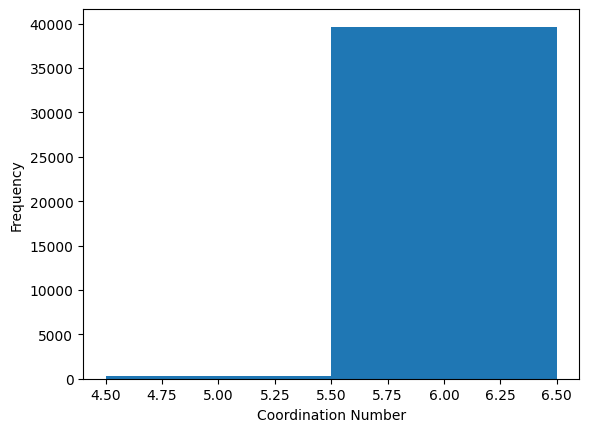

In [ ]:
print(set(y))
plt.hist(y, bins=len(set(y)), align='mid', range=(min(y)-0.5, max(y)+0.5))
plt.xlabel("Coordination Number")
plt.ylabel("Frequency")
plt.show()

In [ ]:
y.count(6)/len(y)

0.9915